In [1]:
using CSV
using Revise
using DataFrames
using StatsBase
using LinearAlgebra
using Distributions

using Stheno
using Measurements
using LogExpFunctions
import ComponentArrays: ComponentArray
using CairoMakie
using ColorSchemes
includet("src/rgp.jl")

# sin(x)

In [2]:
## Dummy test
step_test = 0.03
step_basis = 0.7
std = 0.01
l = 1
batch_size = 9
mu_prior = 0
limit_test = [-8, 8]
limit_basis = [-10, 10]

## Test
X_test = collect(limit_test[1]:step_test:limit_test[2])
Y_test = sin.(X_test) + rand(Normal(0, std), size(X_test)[1])

## Basis
X_basis = collect(limit_basis[1]:step_basis:limit_basis[2])

θ = ComponentArray(;
    l = l,
    mu = mu_prior,
    std = std,
)

p, posterior = rgp(X_basis, X_test, Y_test, θ, batch_size)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.006361302077124392, 0.6023102886783837, 0.5069131268653966, -0.010684816789755788, 0.37430294694804234, 0.0358841574934953, -0.013515287172567494, 0.6609987171660235, 0.6790738048786309]
[0.023618352912519593, -0.42236740510070103, 0.288699867997706, 0.4531418915506826, -0.5454997811820994, -0.004570099609223754, -0.5188465746011736, -0.11486450569544539, 0.20778899551077834]
[-0.13751520073021994, -0.9111242369494242, 0.8175431434845422, 0.8401175167349171, -0.5691634795978594, -0.7114939851984863, -0.5094579550026278, 0.9227353655688793, -0.632925792563132]
[0.4795388045185131, -0.9701098733531193, 0.5846160461098976, -0.2943403854983101, 0.7300970452859478, 0.389818043554496, -0.9137768232736894, -0.6719070356424626, 0.7965928163275697]
[-0.7218853786792472, 0.3327372969772561, -0.1592432763555053, 0.8454303953437565, -0.8090603906520577, -0.06402194297156615, 0.2840676725805871, 0.8867811961607672, 0.04481586066978107]
[0.85043197800

((kernel = Squared Exponential Kernel (metric = Distances.Euclidean(0.0))
	- Scale Transform (s = 1.0), inv_cov_basis = Any[7.853634481296553 -15.868578795198356 … -0.027169533580660522 0.008237786629150264; -15.868578795198419 39.916716321683644 … 0.08960942899936739 -0.027169533580663735; … ; -0.027169533580652258 0.08960942899934858 … 39.91671632169553 -15.868578795201858; 0.008237786629147753 -0.02716953358065798 … -15.86857879520186 7.853634481297505]), Dict{Symbol, Dict{Symbol, Array{Float64}}}(:test => Dict(:mu => [0.8084641102704768, 0.23294997490066746, 0.7234016172192117], :cov => [2.389569234563858e-5 3.9535229616237696e-6 -7.308342002988144e-6; 3.953522969946359e-6 2.8181889191663727e-5 -1.7030907794207425e-5; -7.3083419894194886e-6 -1.703090776912895e-5 2.3947093318610454e-5]), :basis => Dict(:mu => [-0.20388583832128804, -0.4912208875439825, -0.8151478046644282, -0.9979272744796279, -0.7964589184890697, -0.21470562507094804, 0.46578770082703064, 0.9250877385886822, 0.9515

## Plot

In [3]:
limit_predict = [-10, 10]
step_predict = 0.32
X_predict =  collect(limit_predict[1]:step_predict:limit_predict[2])
Y_predict = sin.(X_predict)
mu, C = predict(p, posterior, X_predict)
σ = sqrt.(diag(C))


63-element Vector{Float64}:
 0.8711511061706333
 0.7295951204083282
 0.5457427788151935
 0.34802638897615445
 0.17491238537471532
 0.06148450517821818
 0.012360093473916684
 0.005143932317488948
 0.006263147634174662
 0.003234485494778877
 ⋮
 0.00629024110102249
 0.0043178221511782746
 0.009319211791362128
 0.028487300808284464
 0.10028916542372779
 0.23526776495154655
 0.43340007048252316
 0.6535453938992536
 0.8334521375280757

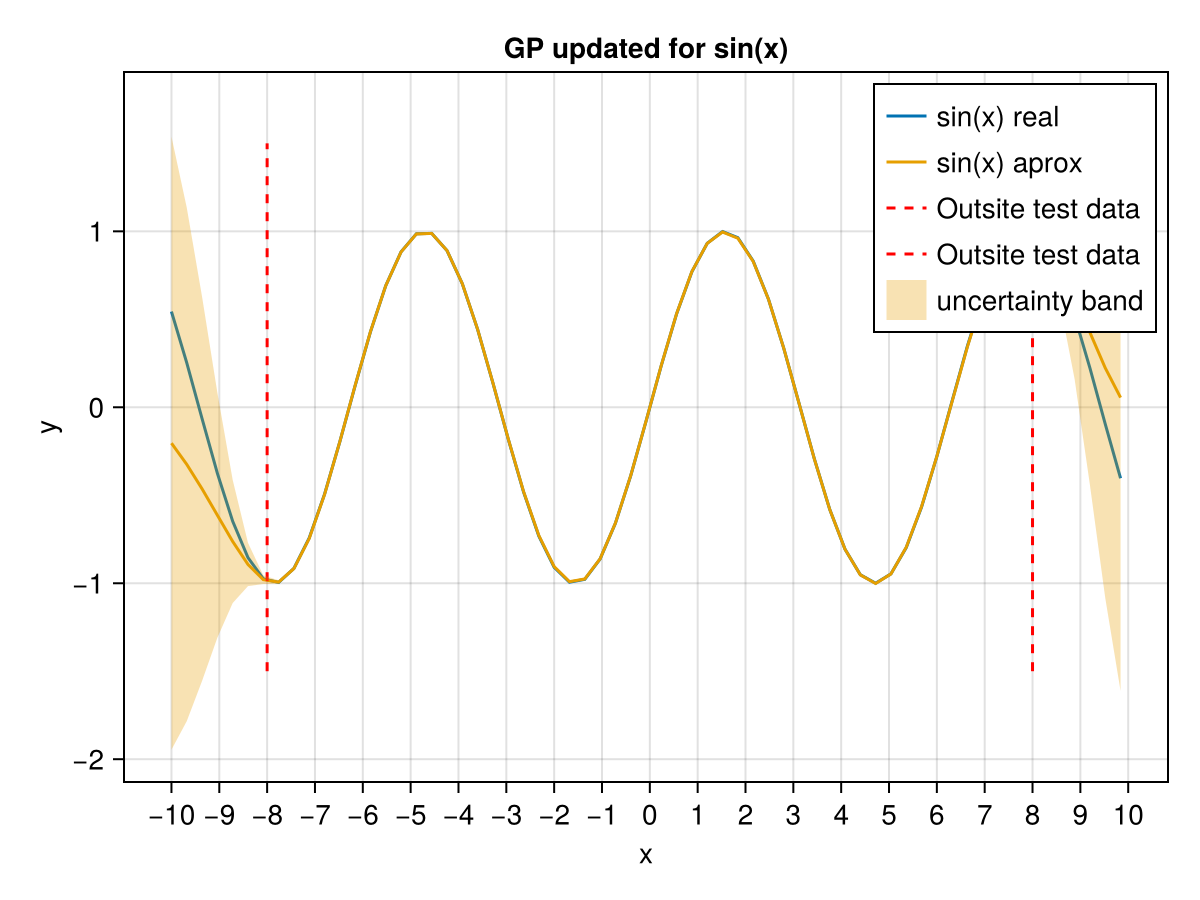

CairoMakie.Screen{IMAGE}


In [4]:
fig = Figure()
ax = Axis(fig[1, 1], title = "GP updated for sin(x)", xlabel = "x", ylabel = "y", xticks = limit_predict[1]:1:limit_predict[2])
lines!(ax, X_predict, Y_predict, label = "sin(x) real")
lines!(ax, X_predict, mu, label = "sin(x) aprox")
lines!(ax, [limit_test[1], limit_test[1]],[-1.5, 1.5], color = :red,  linestyle = :dash, label = "Outsite test data")
lines!(ax, [limit_test[2], limit_test[2]],[-1.5, 1.5], color = :red,  linestyle = :dash, label = "Outsite test data")

band!(ax, X_predict, mu - 2σ, mu + 2σ; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))
axislegend(ax)
display(fig)

# $ x/2 + 25 \cdot x/(1 + x^2) \cdot cos(x) $

In [5]:
## Dummy test
step_test = 0.01
step_basis = 0.8
std = 0.01
l = 1
batch_size = 9
mu_prior = 0
limit_test = [-8, 8]
limit_basis = [-10, 10]

## Test
X_test = collect(limit_test[1]:step_test:limit_test[2])
Y_test = X_test/2 + 25*X_test./(1 .+ X_test.^2) .* cos.(X_test) + rand(Normal(0, std), size(X_test)[1])


## Basis
X_basis = collect(limit_basis[1]:step_basis:limit_basis[2])

θ = ComponentArray(;
    l = l,
    mu = mu_prior,
    std = std,
)

p, posterior = rgp(X_basis, X_test, Y_test, θ, batch_size)


[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[3.3696619779599932, 4.674119479175023, -1.304432543781579, 6.9553926021193595, 0.7056513918014613, -0.8167472597323961, -1.8070915006879307, 3.155190815241458, 0.5560446651165499]
[-2.8879142788337044, -5.592464308402336, -6.727863470931748, -5.9710749656392155, -2.4544786672490733, -2.184422607956938, 3.0805888884582937, -2.2961498044142163, -2.7792399649136237]
[-5.255227618883051, -1.0096230002473976, -0.11847177255883845, 3.21083852537742, -9.311240536713411, 9.618986507582266, -4.910577557728961, 0.24727967040985924, 3.880319793600817]
[-6.229458921796204, -3.1645149466722247, 5.147124862158055, -6.53832784807716, -3.381222561268772, 3.3846095838056205, 2.730140710844389, -0.5925265087290651, 4.015367998100811]
[0.2275777404742349, 6.994608434714446, -3.215647733701066, 2.6391193910421467, -6.3425602416459075, 3.4246461535210075, 6.252573857431729, -7.105136430182362, 4.661355995700589]
[-6.908246874943697, -6.922232088950317, -6.8193

((kernel = Squared Exponential Kernel (metric = Distances.Euclidean(0.0))
	- Scale Transform (s = 1.0), inv_cov_basis = Any[4.061127330715571 -6.238493983936311 … 0.003968920262419481 -0.0013623564466084346; -6.238493983936314 13.644379014856995 … -0.011562559370889989 0.003968920262419486; … ; 0.003968920262419157 -0.011562559370889035 … 13.64437901485702 -6.238493983936324; -0.001362356446608326 0.003968920262419165 … -6.238493983936326 4.061127330715577]), Dict{Symbol, Dict{Symbol, Array{Float64}}}(:test => Dict(:mu => [4.609741184886349, -5.267487518165308, -5.950341123774779, -4.2551795853646786, 1.6015473240902371, -3.5486878766814263, 5.897277969578503, -5.842480839697331], :cov => [4.1494494974382454e-6 4.547784812030912e-6 … 4.059147267361829e-7 -8.611906305427784e-8; 4.5477848086052735e-6 0.00020759975227019974 … 3.969792128017073e-5 -8.983094226128424e-6; … ; 4.0591472637423795e-7 3.969792128438521e-5 … 0.000261247391577159 -0.00012601853153939817; -8.611906307702971e-8 -8.9

In [6]:
limit_predict = [-10, 10]
step_predict = 0.02
X_predict =  collect(limit_predict[1]:step_predict:limit_predict[2])
Y_predict = X_predict/2 + 25*X_predict./(1 .+ X_predict.^2) .* cos.(X_predict)
mu, C = predict(p, posterior, X_predict)
σ = sqrt.(diag(C))


1001-element Vector{Float64}:
 0.8522615506275933
 0.8433721572409965
 0.8341456272538176
 0.824587090932699
 0.814702629437221
 0.8044992631370383
 0.7939849360781119
 0.7831684966271008
 0.7720596743373689
 0.760669053092818
 ⋮
 0.779004499439552
 0.7900317608751148
 0.8007645346808221
 0.8111931955702235
 0.8213089974912917
 0.8311040968333966
 0.8405715718595929
 0.8497054383201242
 0.8585006612175304

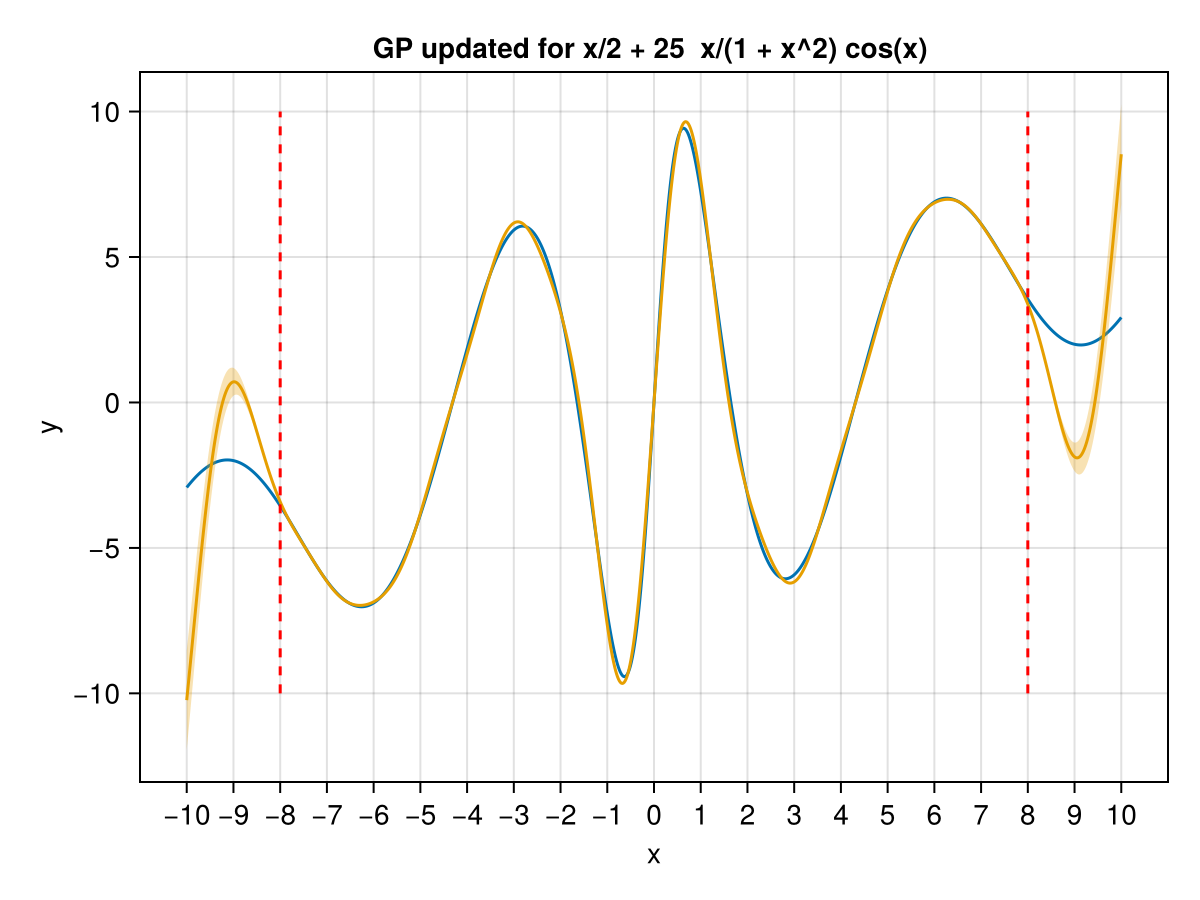

CairoMakie.Screen{IMAGE}


In [7]:
fig = Figure()
ax = Axis(fig[1, 1], title = "GP updated for x/2 + 25  x/(1 + x^2) cos(x) ", xlabel = "x", ylabel = "y", xticks = limit_predict[1]:1:limit_predict[2])
lines!(ax, X_predict, Y_predict, label = "f(x) real")
lines!(ax, X_predict, mu, label = "f(x) aprox")
lines!(ax, [limit_test[1], limit_test[1]],[-10, 10], color = :red,  linestyle = :dash, label = "Outsite test data")
lines!(ax, [limit_test[2], limit_test[2]],[-10, 10], color = :red,  linestyle = :dash, label = "Outsite test data")

band!(ax, X_predict, mu - 2σ, mu + 2σ; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))
display(fig)